<a href="https://colab.research.google.com/github/sanghavividhi/Natural-Language-Processing-NLP-/blob/main/19_08_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**POS** **Tagging**-***NLTK***

In [ ]:
import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
from nltk import word_tokenize,pos_tag

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
# Tokenize the sentence
text="The quick brown fox jumps over the lazy dog."
tokens=word_tokenize(text)
print(tokens)

['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']
[('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]


In [ ]:
#Apply POS Tagging
tagged = pos_tag(tokens)
print(tagged)

[('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]


In [ ]:
# show only verb tokens
verb_tokens = [word for word, pos in tagged if pos.startswith('VB')]
print("Verb Tokens:",verb_tokens)

Verb Tokens: ['jumps']


In [ ]:
#show only noun tokens
noun_tokens = [word for word, pos in tagged if pos.startswith('NN')]
print("Noun Tokens:",noun_tokens)

Noun Tokens: ['brown', 'fox', 'dog']


In [ ]:
#show both verb and noun
tokens = [word for word, pos in tagged if pos.startswith(('VB','NN'))]
print("Tokens:",tokens)

Tokens: ['brown', 'fox', 'jumps', 'dog']


**WITH** **SPACY**

In [ ]:
import spacy
nlp=spacy.load('en_core_web_sm')

In [ ]:
#Process text into a Doc object
text="The quick brown fox jumps over the lazy dog."
doc=nlp(text)

In [ ]:
#Read coarse(pos_) and fine (tag_) tags
for token in doc:
  print(token.text,token.pos_,token.tag_)

The DET DT
quick ADJ JJ
brown ADJ JJ
fox NOUN NN
jumps VERB VBZ
over ADP IN
the DET DT
lazy ADJ JJ
dog NOUN NN
. PUNCT .


In [ ]:
verb_tokens = [token.text for token in doc if token.pos_ == 'VERB']
print("Verb Tokens:",verb_tokens)

Verb Tokens: ['jumps']


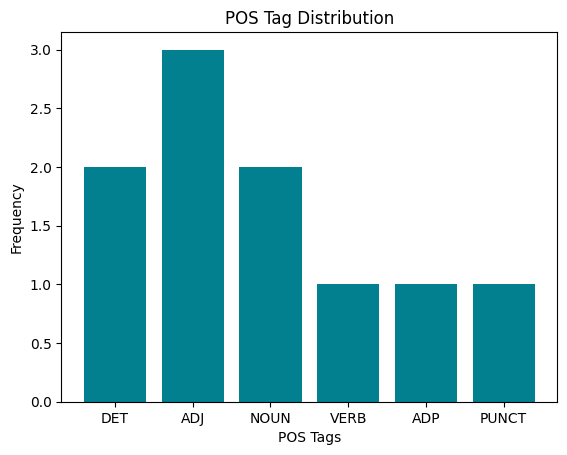

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

tags = [token.pos_ for token in doc]
counts = Counter(tags)

plt.bar(counts.keys(), counts.values(),color='#028090')
plt.xlabel('POS Tags')
plt.ylabel('Frequency')
plt.title('POS Tag Distribution')
plt.show()

**Named** **Entity** **Recognition** - *Only
spacy*

In [ ]:
import spacy
nlp=spacy.load('en_core_web_sm')

In [ ]:
#Process text into Doc Object
text=("Google was founded in 1985 by Larry Page and Sergey Brin to organize the world's information and make it universall accessible and useful")
doc=nlp(text)

In [ ]:
#Read recognized entities
for ent in doc.ents:
  print(ent.text,ent.label_)

Google ORG
1985 DATE
Larry Page PERSON
Sergey Brin PERSON


In [ ]:
from spacy import displacy
#Display named entities in colab
displacy.render(doc,style='ent')
# save Visualization as HTML
html=displacy.render(doc,style='ent',jupyter=False,page=True)
with open('entities.html','w',encoding='utf-8') as f:
  f.write(html)

#Download HTML file
from google.colab import files
files.download('entities.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Task 1 — Import file and POS tag every sentence

In [ ]:
from collections import Counter

# Keep only PERSON and ORG entities
people = [e.text for e in doc.ents
          if e.label_ == "PERSON"]
orgs = [e.text for e in doc.ents
        if e.label_ == "ORG"]

# Count how many of each label appear
labels = [e.label_ for e in doc.ents]
print(Counter(labels))
# Counter({'ORG': 1, 'PERSON': 1, 'DATE': 1})

Counter({'ORG': 2, 'CARDINAL': 1, 'DATE': 1})


In [ ]:
import nltk
from nltk import word_tokenize, pos_tag

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Import / read file
with open("pos_sample.txt", "r") as file:
    sentences = file.readlines()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [ ]:
# POS tagging
for sentence in sentences:
    tokens = word_tokenize(sentence)
    tagged = pos_tag(tokens)

    print(tagged)

[('The', 'DT'), ('quick', 'JJ'), ('brown', 'NN'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN'), ('.', '.')]
[('Priya', 'NNP'), ('is', 'VBZ'), ('reading', 'VBG'), ('an', 'DT'), ('interesting', 'JJ'), ('book', 'NN'), ('about', 'IN'), ('artificial', 'JJ'), ('intelligence', 'NN'), ('.', '.')]
[('Students', 'NNS'), ('must', 'MD'), ('submit', 'VB'), ('their', 'PRP$'), ('assignments', 'NNS'), ('before', 'IN'), ('the', 'DT'), ('deadline', 'NN'), ('.', '.')]
[('The', 'DT'), ('GLS', 'NNP'), ('University', 'NNP'), ('campus', 'NN'), ('looks', 'VBZ'), ('beautiful', 'JJ'), ('during', 'IN'), ('the', 'DT'), ('monsoon', 'NN'), ('season', 'NN'), ('.', '.')]
[('He', 'PRP'), ('quickly', 'RB'), ('finished', 'VBD'), ('his', 'PRP$'), ('homework', 'NN'), ('and', 'CC'), ('went', 'VBD'), ('outside', 'IN'), ('to', 'TO'), ('play', 'VB'), ('cricket', 'NN'), ('.', '.')]
[('Natural', 'JJ'), ('Language', 'NNP'), ('Processing', 'NNP'), ('helps', 'VBZ'), ('computers', 'N

Task 2 — Count and plot POS tags from the imported file

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


POS Tag Frequencies:
DT : 11
JJ : 13
NN : 20
VBZ : 5
IN : 7
. : 10
NNP : 7
VBG : 2
NNS : 6
MD : 2
VB : 4
PRP$ : 3
PRP : 2
RB : 2
VBD : 3
CC : 2
TO : 2
VBP : 2


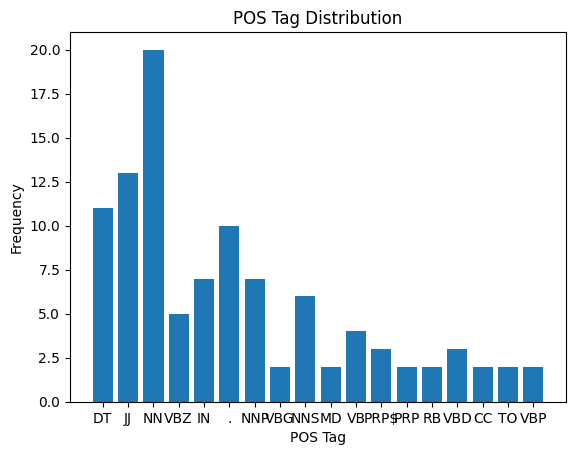

In [ ]:
import nltk
from nltk import word_tokenize, pos_tag
from collections import Counter
import matplotlib.pyplot as plt

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

# Import file
with open("pos_sample.txt", "r") as file:
    sentences = file.readlines()

all_tags = []

# POS tagging
for sentence in sentences:
    tokens = word_tokenize(sentence)
    tagged = pos_tag(tokens)

    for word, tag in tagged:
        all_tags.append(tag)

# Count POS tags
counts = Counter(all_tags)

print("POS Tag Frequencies:")
for tag, count in counts.items():
    print(tag, ":", count)

# Plot
plt.bar(counts.keys(), counts.values())
plt.xlabel("POS Tag")
plt.ylabel("Frequency")
plt.title("POS Tag Distribution")
plt.show()

Task 3 — Noun & Verb Extractor using imported file

In [ ]:
import nltk
from nltk import word_tokenize, pos_tag

nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:
def extract_nouns_verbs(text):
    tokens = word_tokenize(text)
    tagged = pos_tag(tokens)

    nouns = []
    verbs = []

    for word, tag in tagged:
        if tag.startswith("NN"):
            nouns.append(word)
        elif tag.startswith("VB"):
            verbs.append(word)

    return nouns, verbs


# Import file
with open("pos_sample.txt", "r") as file:
    text = file.read()

# Extract nouns and verbs
nouns, verbs = extract_nouns_verbs(text)

print("Nouns:", nouns)
print("Verbs:", verbs)

Nouns: ['brown', 'fox', 'dog', 'Priya', 'book', 'intelligence', 'Students', 'assignments', 'deadline', 'GLS', 'University', 'campus', 'monsoon', 'season', 'homework', 'cricket', 'Language', 'Processing', 'computers', 'language', 'smartphone', 'camera', 'battery', 'team', 'mini', 'project', 'Friday', 'afternoon', 'result', 'Data', 'scientists', 'datasets', 'patterns']
Verbs: ['jumps', 'is', 'reading', 'submit', 'looks', 'finished', 'went', 'play', 'helps', 'understand', 'has', 'present', 'smiled', 'receiving', 'analyze', 'discover']


Task 1 — Extract Entities from Every Sentence


In [ ]:
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Import / read file
with open("ner_sample.txt", "r", encoding="utf-8") as file:
    sentences = file.readlines()

# Extract entities from every sentence
for sentence in sentences:
    doc = nlp(sentence)

    print("\nSentence:", sentence.strip())
    for ent in doc.ents:
        print(ent.text, "->", ent.label_)


Sentence: Elon Musk founded SpaceX in 2002 to reduce space transportation costs.
Elon Musk -> PERSON
2002 -> DATE

Sentence: GLS University is located in Ahmedabad, Gujarat.
GLS University -> ORG
Ahmedabad -> GPE
Gujarat -> GPE

Sentence: Apple reported a revenue of $394 billion in 2022.
Apple -> ORG
$394 billion -> MONEY
2022 -> DATE

Sentence: Narendra Modi visited Japan last week to discuss trade agreements.
Narendra Modi -> PERSON
Japan -> GPE
last week -> DATE

Sentence: Google was founded by Larry Page and Sergey Brin in September 1998.
Google -> ORG
Larry Page -> PERSON
Sergey Brin -> PERSON
September 1998 -> DATE

Sentence: The Reserve Bank of India increased the repo rate by 25 basis points.
The Reserve Bank of India -> ORG
25 -> CARDINAL

Sentence: Amazon plans to open a new warehouse in Mumbai by December 2026.
Amazon -> ORG
Mumbai -> GPE
December 2026 -> DATE

Sentence: Serena Williams won the Australian Open in Melbourne.
Serena Williams -> PERSON
the Australian Open -> E

Task 2 — Count & Plot Entity Label Frequency


Entity Label Frequencies:
PERSON : 5
DATE : 7
ORG : 9
GPE : 5
MONEY : 2
CARDINAL : 2
EVENT : 1


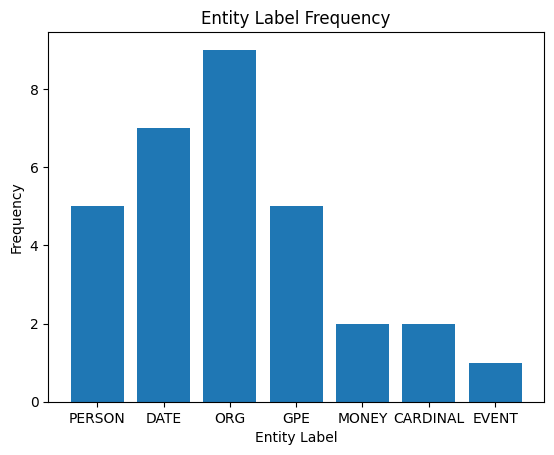

In [ ]:
import spacy
from collections import Counter
import matplotlib.pyplot as plt

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Import / read file
with open("ner_sample.txt", "r", encoding="utf-8") as file:
    sentences = file.readlines()

# Store all entity labels
all_labels = []

# Process every sentence
for sentence in sentences:
    doc = nlp(sentence)

    for ent in doc.ents:
        all_labels.append(ent.label_)

# Count entity labels
counts = Counter(all_labels)

print("Entity Label Frequencies:")

for label, count in counts.items():
    print(label, ":", count)

# Plot bar chart
plt.bar(counts.keys(), counts.values())
plt.xlabel("Entity Label")
plt.ylabel("Frequency")
plt.title("Entity Label Frequency")
plt.show()

Task 3 — Entity Redactor


In [ ]:
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

def redact_entities(text, labels):
    doc = nlp(text)

    result = text

    # Replace entities from right to left
    for ent in reversed(doc.ents):
        if ent.label_ in labels:
            result = result[:ent.start_char] + "[REDACTED]" + result[ent.end_char:]

    return result


# Import / read file
with open("ner_sample.txt", "r", encoding="utf-8") as file:
    text = file.read()

# Test the function
labels = ["PERSON", "ORG", "GPE", "MONEY", "DATE"]

redacted_text = redact_entities(text, labels)

print(redacted_text)

[REDACTED] founded SpaceX in [REDACTED] to reduce space transportation costs.
[REDACTED] is located in [REDACTED], [REDACTED].
[REDACTED] reported a revenue of [REDACTED] in [REDACTED].
[REDACTED] visited [REDACTED] [REDACTED] to discuss trade agreements.
[REDACTED] was founded by [REDACTED] and [REDACTED] in [REDACTED].
[REDACTED] increased the repo rate by 25 basis points.
[REDACTED] plans to open a new warehouse in [REDACTED] by [REDACTED].
[REDACTED] won the Australian Open in [REDACTED].
[REDACTED] acquired [REDACTED] for [REDACTED] in [REDACTED].
[REDACTED] in [REDACTED] attracts millions of tourists [REDACTED].

